In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import datetime as dt
import matplotlib as mpl
import networkx as nx
import scipy.io as sio
import scipy.sparse as sps
from datetime import date, timedelta
from sqlalchemy import create_engine
from matplotlib import pyplot as plt
from matplotlib import rcParams
from importlib import reload
import sys
import seaborn as sns
import scipy
from tqdm import tqdm
from matplotlib.patches import Patch
import utils_comparison as uc
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# plot distribution of cluster sizes

def plot_cluster_size_dist(clusters_A, clusters_B, name_A, name_B, naming):
    clusters_A[naming]=name_A
    clusters_B[naming] = name_B
    clusters = pd.concat([clusters_A, clusters_B])

    sizes_A = pd.DataFrame(clusters_A['size']/clusters_A['size'].sum())
    sizes_A[naming] = name_A

    sizes_B = pd.DataFrame(clusters_B['size']/clusters_B['size'].sum())
    sizes_B[naming] = name_B

    sizes = pd.concat([sizes_A, sizes_B])
    sns.histplot(x='size', hue=naming, multiple='dodge',data=sizes, log_scale= True, palette=['steelblue','indianred'],alpha=.7, bins=15, shrink=0.8)
    plt.xlabel('Cluster sizes [% of observations]')
    os.makedirs('figures', exist_ok=True)
    plt.savefig(f'figures/cluster_size_comparison_{name_A}_{name_B}.pdf')

In [3]:
def print_minmax_clusters(clusters, var, max=True):
    if max:
        clusters.sort_values(var, ascending=False, inplace=True)
    else:
        clusters.sort_values(var, ascending=True, inplace=True)

    for i, row in clusters[1:5].iterrows():
        try:
            print(row['order'])
        except:
            print(i)
        print(row[var])
        print(row['size']/clusters['size'].sum())
        print(row['conditions'][['condition','from_ICD','to_ICD']].merge(blocks, how='left', on = ['from_ICD','to_ICD']))

In [4]:
with open('blocks.pkl','rb') as f:
    blocks = pickle.load(f)
clusters_AT_replication = pd.read_csv('clusters_AT_replication.csv')
clusters_AT_original = pd.read_csv('clusters_AT_original.csv')

# per-cluster demographics for the distribution panels (Fig 3a)
# DK: data/nodes_DK_pop_DK_clusters.csv -> cluster, mean_age, age_q25/age_median/age_q75, female_ratio,
#     size, size_alive, mortality_rate (= in-hospital deaths / alive person-years; blank if < 5 deaths)
# AT: clusters_AT_original.csv          -> order, size, female_ratio, mean_age, mortality_rate (alive person-years)
demo_DK = pd.read_csv('data/nodes_DK_pop_DK_clusters.csv')
demo_AT = clusters_AT_original.drop_duplicates('order').reset_index(drop=True)  # one row per cluster

# the zero cluster (no recorded diagnoses) is excluded from all distribution panels
demo_DK_nz = demo_DK[demo_DK['cluster'] != 0].reset_index(drop=True)
demo_AT_nz = demo_AT[demo_AT['order'] != 0].reset_index(drop=True)

# Comparison of Clusters by Haug et al. 2020 to Replication Attempt

In [5]:
# gather conditions
conditions_replication_true = uc.gather_criteria(clusters_AT_replication)
conditions_original_true = uc.gather_criteria(clusters_AT_original)
conditions_original_true = conditions_original_true.reset_index().drop('index',axis=1)
conditions_replication_false = uc.gather_criteria(clusters_AT_replication,False)
conditions_original_false = uc.gather_criteria(clusters_AT_original,False)
conditions_original_false = conditions_original_false.reset_index().drop('index',axis=1)

In [6]:
# find perfect matches
diffs = np.zeros([132,132])
for i in range(132):
    for j in range(132):
        cond_diff = np.sum(np.abs(conditions_original_true.loc[i,:]- conditions_replication_true.loc[j,:]))
        diffs[i,j]=cond_diff
# perfect matches
perfect_matches = np.where(diffs==0)
perfect_matches = pd.DataFrame([perfect_matches[0],perfect_matches[1]]).T.rename(columns={0:'AT_paper_cluster',1:'AT_cluster_match'})
perfect_matches['diff']='-'
perfect_matches = perfect_matches.drop([0,3],axis=0)
perfect_matches

,AT_paper_cluster,AT_cluster_match,diff
1,0,1,-
2,0,2,-
4,0,4,-
5,0,5,-
6,0,6,-
...,...,...,...
17419,131,127,-
17420,131,128,-
17421,131,129,-
17422,131,130,-


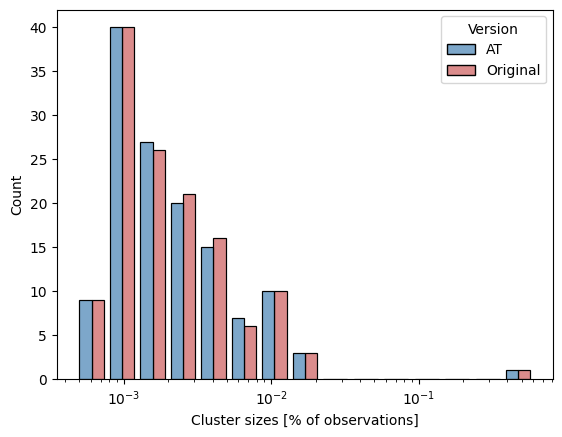

In [7]:
plot_cluster_size_dist(clusters_AT_replication, clusters_AT_original,'AT','Original','Version')

# Compare Cluster Size Distribution in Denmark and Austria

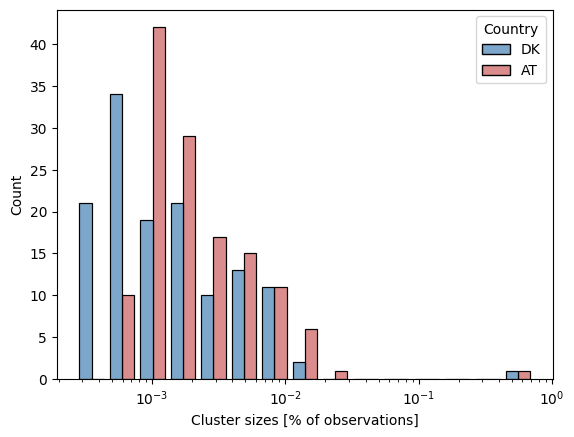

In [8]:
plot_cluster_size_dist(demo_DK,demo_AT,'DK','AT','Country')


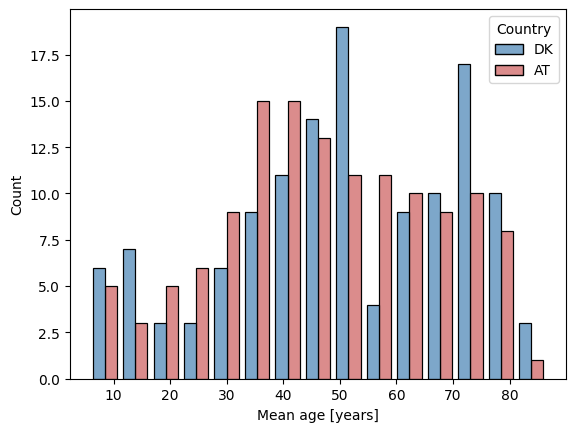

In [9]:
# compare mean cluster age distribution (observation-weighted mean age, zero cluster excluded)

DK_age_stats = pd.DataFrame(demo_DK_nz['mean_age']).rename(columns={'mean_age': 'Mean age'})
DK_age_stats['Country'] = 'DK'

AT_age_stats = pd.DataFrame(demo_AT_nz['mean_age']).rename(columns={'mean_age': 'Mean age'})
AT_age_stats['Country'] = 'AT'

age_stats = pd.concat([DK_age_stats,AT_age_stats], axis=0).reset_index(drop=True)
# plot
sns.histplot(x='Mean age', hue='Country', multiple='dodge',data=age_stats,  palette=['steelblue','indianred'],alpha=.7, bins=15, shrink=0.8)
plt.xlabel('Mean age [years]')
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/age_comparison_DK_AT.pdf', bbox_inches='tight')

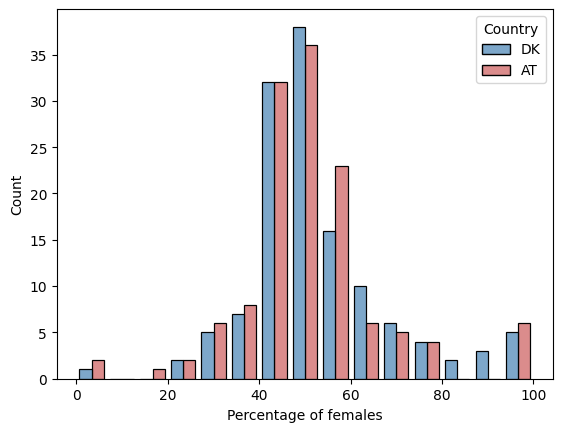

In [10]:
# compare mean cluster female ratio distribution

DK_gender_stats = pd.DataFrame(demo_DK_nz['female_ratio']).rename(columns={'female_ratio': 'Female ratio'})
DK_gender_stats['Country'] = 'DK'

AT_gender_stats = pd.DataFrame(demo_AT_nz['female_ratio']).rename(columns={'female_ratio':'Female ratio'})
AT_gender_stats['Country'] = 'AT'

gender_stats = pd.concat([DK_gender_stats,AT_gender_stats], axis=0).reset_index(drop=True)

gender_stats['Female ratio'] = gender_stats['Female ratio']*100
sns.histplot(x='Female ratio', hue='Country', multiple='dodge',data=gender_stats,  palette=['steelblue','indianred'],alpha=.7, bins=15, shrink=0.8)
plt.xlabel('Percentage of females')
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/female_ratio_comparison_DK_AT.pdf', bbox_inches='tight')

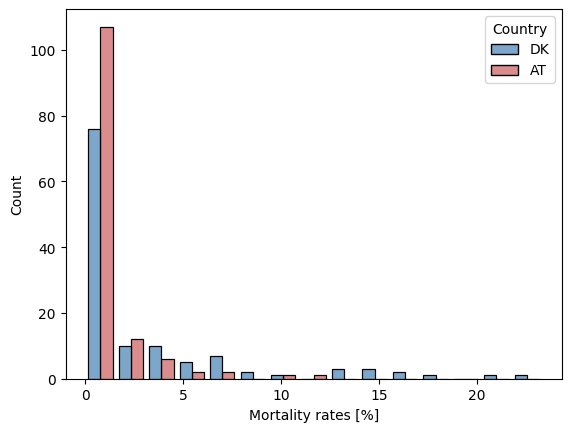

In [11]:
# compare mortality rate distribution
# both rates: in-hospital deaths per alive person-year (zero cluster excluded)

DK_mortality_stats = pd.DataFrame(demo_DK_nz['mortality_rate']).rename(columns={'mortality_rate': 'Mortality rate'})
DK_mortality_stats['Country'] = 'DK'

AT_mortality_stats = pd.DataFrame(demo_AT_nz['mortality_rate']).rename(columns={'mortality_rate': 'Mortality rate'})
AT_mortality_stats['Country'] = 'AT'

mortality_stats = pd.concat([DK_mortality_stats,AT_mortality_stats], axis=0).reset_index(drop=True)

mortality_stats['Mortality rate'] = mortality_stats['Mortality rate']*100

sns.histplot(x='Mortality rate', hue='Country', multiple='dodge',data=mortality_stats,  palette=['steelblue','indianred'],alpha=.7, bins=15, shrink=0.8)
plt.xlabel('Mortality rates [%]')
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/mortality_comparison_DK_AT.pdf', bbox_inches='tight')

In [12]:
# cluster size as % of all observations (denominator includes the zero cluster; zero cluster itself not plotted)
sizes_A = pd.DataFrame(demo_DK_nz['size']/demo_DK['size'].sum())
sizes_A['Country'] = 'DK'
sizes_B = pd.DataFrame(demo_AT_nz['size']/demo_AT['size'].sum())
sizes_B['Country'] = 'AT'

sizes = pd.concat([sizes_A, sizes_B]).reset_index(drop=True)
sizes["size"] = sizes["size"]*100
sizes = sizes.rename(columns={"size": "Size [%]"})

age_stats = age_stats.rename(columns={"Mean age": "Mean Age [years]"})
gender_stats = gender_stats.rename(columns={"Female ratio":"Female Ratio [%]"})
mortality_stats = mortality_stats.rename(columns={'Mortality rate': "Mortality Rate [%]"})

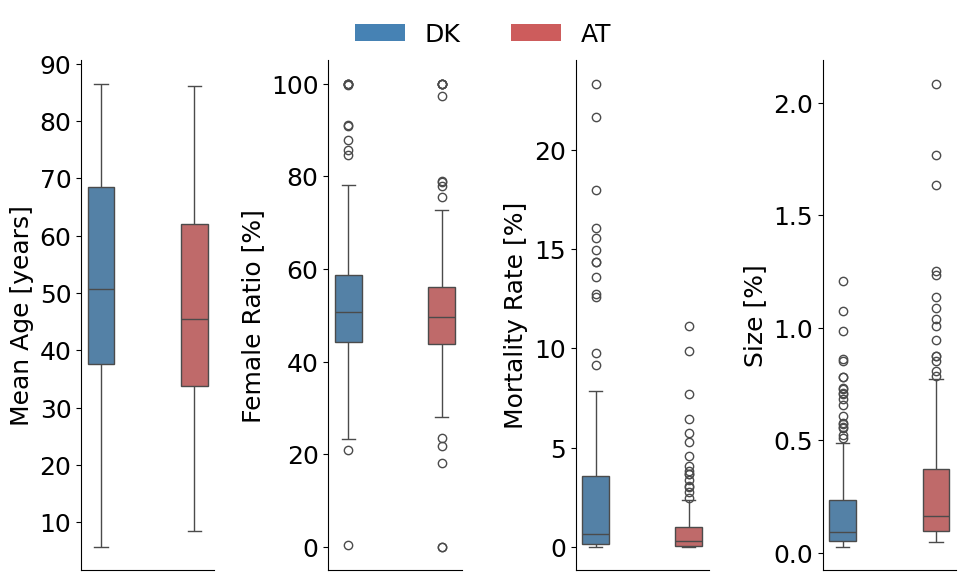

In [13]:
# create boxplot with overview
dfs = [age_stats, gender_stats, mortality_stats, sizes]
plt.rcParams.update({'font.size':18})

fig, axes = plt.subplots(1,4, figsize=(10,6), sharey=False)
for ax, df in zip(axes, dfs):
    sns.boxplot(hue=df.columns[1], y=df.columns[0], x="Country", data= df, palette=['steelblue','indianred'],ax=ax, width=0.8, dodge=True)
    if ax.legend_ is not None:
        ax.legend_.remove()
    ax.set_xlabel('')
    ax.set_xticks([])
    sns.despine(ax=ax, top=True, right=True)
handles = [Patch(facecolor=col, label=lab) for col, lab in zip(['steelblue','indianred'], ['DK','AT'])]
labels = ['DK','AT']
fig.legend(handles, labels, loc='upper center',ncol=2, frameon=False)
plt.tight_layout(rect=[0,0,1,0.95])
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/overview_boxplot_DK_AT.pdf', bbox_inches='tight')
